# **Análise dos Casos de Dengue no Brasil em 2026**

##### **Alunos:** Giovanna Coelho Gilio de Sá | Eduardo Nascimento Couto Luiz
---

Este trabalho apresenta uma análise exploratória dos casos de dengue registrados em 2026, utilizando dados epidemiológicos para identificar padrões relacionados à faixa etária, distribuição geográfica, evolução temporal e frequência de sintomas. Por meio de técnicas de análise de dados e visualização, busca-se compreender o perfil dos casos registrados e destacar os principais padrões observados na base analisada.

## **1. Arquitetura Medalhão**

A arquitetura utilizada no projeto segue o modelo Medalhão (Medallion Architecture), que organiza o processamento dos dados em diferentes camadas. Cada camada possui uma finalidade específica, permitindo que os dados evoluam de seu formato original para uma estrutura mais organizada e adequada às etapas posteriores de análise.

No projeto de análise dos casos de dengue, o fluxo parte dos dados originais em formato CSV e passa por etapas de armazenamento, tratamento e preparação. Após essas etapas, os dados tratados são utilizados para a realização das análises e visualizações.

## **2. Camada Bronze**

A camada Bronze representa os dados em seu estado original, mantendo as informações próximas ao formato disponibilizado pela fonte.

Nesta etapa, o arquivo mosq_deng_26_csl.csv é carregado para um DataFrame utilizando a biblioteca Pandas. O objetivo é preservar os dados originais antes da aplicação de processos de limpeza ou transformação, mantendo uma referência para as informações recebidas inicialmente.

#### **2.1 Importação de bibliotecas e de dados**

In [73]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [75]:
df = pd.read_csv(
    "mosq_deng_25_csl.csv",
    encoding="latin1",
    sep=","
)

C:\Users\49048057809\AppData\Local\Temp\ipykernel_17280\3121401633.py:1: DtypeWarning: Columns (22,44,52,54,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## **3. Camada Silver**

#### **3.1 Visualizando o DataFrame**

In [76]:
# lendo primeiras linhas
df.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2024-12-29,202501,2024,32,320070,32004,2485397.0,2024-12-29,...,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0
1,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025.0,2024-12-29,...,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0
2,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025.0,2024-12-29,...,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0
3,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025.0,2024-12-29,...,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0
4,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025.0,2024-12-29,...,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0


In [77]:
# tamanho do meu dataframe
df.shape

(1643215, 121)

In [78]:
# verificando valores nulos
df.isnull().sum()

TP_NOT              0
ID_AGRAVO           0
DT_NOTIFIC          0
SEM_NOT             0
NU_ANO              0
SG_UF_NOT           0
ID_MUNICIP          0
ID_REGIONA          0
ID_UNIDADE        162
DT_SIN_PRI          0
SEM_PRI             0
ANO_NASC         4607
NU_IDADE_N          0
CS_SEXO             2
CS_GESTANT        186
CS_RACA             4
CS_ESCOL_N     303701
SG_UF               0
ID_MN_RESI          9
ID_RG_RESI      30062
ID_PAIS             0
DT_INVEST       51904
ID_OCUPA_N    1170476
FEBRE           51929
MIALGIA         51929
CEFALEIA        51929
EXANTEMA        51929
VOMITO          51929
NAUSEA          51929
DOR_COSTAS      51929
CONJUNTVIT      51929
ARTRITE         51929
ARTRALGIA       51929
PETEQUIA_N      51929
LEUCOPENIA      51929
LACO            51929
DOR_RETRO       51929
DIABETES        51929
HEMATOLOG       51929
HEPATOPAT       51929
RENAL           51929
HIPERTENSA      51929
ACIDO_PEPT      51929
AUTO_IMUNE      51929
DT_CHIK_S1    1643214
DT_CHIK_S2

In [79]:
nulos = pd.DataFrame({
    "quantidade_nulos": df.isnull().sum(),
    "porcentagem_nulos": (df.isnull().sum() / len(df)) * 100
})

# nulos = nulos[nulos["quantidade_nulos"] > 0]

nulos = nulos.sort_values(
    "quantidade_nulos",
    ascending=False
)

pd.set_option("display.max_rows", None)

print(nulos)

            quantidade_nulos  porcentagem_nulos
DT_CHIK_S2           1643215         100.000000
DT_PRNT              1643215         100.000000
DT_CHIK_S1           1643214          99.999939
DT_OBITO             1640817          99.854067
DT_GRAV              1639914          99.799113
DT_NS1               1639396          99.767590
DT_VIRAL             1634682          99.480713
EPISTAXE             1608963          97.915550
RES_CHIKS2           1608963          97.915550
RESUL_PRNT           1608963          97.915550
RESUL_SORO           1608963          97.915550
RESUL_NS1            1608963          97.915550
CLINC_CHIK           1608963          97.915550
MANI_HEMOR           1608963          97.915550
MIGRADO_W            1608963          97.915550
GENGIVO              1608963          97.915550
EVIDENCIA            1608963          97.915550
PETEQUIAS            1608963          97.915550
HEMATURA             1608963          97.915550
FLXRECEBI            1608963          97

#### **3.2 Padronização | Renomeando Colunas**

In [80]:
# renomeando todas as colunas do df
df = df.rename(columns={
    "TP_NOT": "tipo_notificacao",
    "ID_AGRAVO": "id_agravo",
    "DT_NOTIFIC": "data_notificacao",
    "SEM_NOT": "semana_notificacao",
    "NU_ANO": "ano",
    "SG_UF_NOT": "uf_notificacao",
    "ID_MUNICIP": "id_municipio_notificacao",
    "ID_REGIONA": "id_regional",
    "ID_UNIDADE": "id_unidade",
    "DT_SIN_PRI": "data_primeiros_sintomas",
    "SEM_PRI": "semana_primeiros_sintomas",
    "ANO_NASC": "ano_nascimento",
    "NU_IDADE_N": "idade",
    "CS_SEXO": "sexo",
    "CS_GESTANT": "gestante",
    "CS_RACA": "raca",
    "CS_ESCOL_N": "escolaridade",
    "SG_UF": "uf",
    "ID_MN_RESI": "id_municipio_residencia",
    "ID_RG_RESI": "id_regional_residencia",
    "ID_PAIS": "id_pais",
    "DT_INVEST": "data_investigacao",
    "ID_OCUPA_N": "id_ocupacao",

    "FEBRE": "febre",
    "MIALGIA": "mialgia",
    "CEFALEIA": "cefaleia",
    "EXANTEMA": "exantema",
    "VOMITO": "vomito",
    "NAUSEA": "nausea",
    "DOR_COSTAS": "dor_costas",
    "CONJUNTVIT": "conjuntivite",
    "ARTRITE": "artrite",
    "ARTRALGIA": "artralgia",
    "PETEQUIA_N": "petequias",
    "LEUCOPENIA": "leucopenia",
    "LACO": "teste_laco",
    "DOR_RETRO": "dor_retro_orbital",
    "DIABETES": "diabetes",
    "HEMATOLOG": "doenca_hematologica",
    "HEPATOPAT": "hepatopatia",
    "RENAL": "doenca_renal",
    "HIPERTENSA": "hipertensao",
    "ACIDO_PEPT": "ulcera_peptica",
    "AUTO_IMUNE": "doenca_autoimune",

    "DT_CHIK_S1": "data_chikungunya_s1",
    "DT_CHIK_S2": "data_chikungunya_s2",
    "DT_PRNT": "data_prnt",
    "RES_CHIKS1": "resultado_chikungunya_s1",
    "RES_CHIKS2": "resultado_chikungunya_s2",
    "RESUL_PRNT": "resultado_prnt",

    "DT_SORO": "data_sorologia",
    "RESUL_SORO": "resultado_sorologia",
    "DT_NS1": "data_ns1",
    "RESUL_NS1": "resultado_ns1",
    "DT_VIRAL": "data_isolamento_viral",
    "RESUL_VI_N": "resultado_isolamento_viral",
    "DT_PCR": "data_pcr",
    "RESUL_PCR_": "resultado_pcr",
    "SOROTIPO": "sorotipo",
    "HISTOPA_N": "histopatologia",
    "IMUNOH_N": "imuno_histoquimica",

    "HOSPITALIZ": "hospitalizacao",
    "DT_INTERNA": "data_internacao",
    "UF": "uf_internacao",
    "MUNICIPIO": "municipio_internacao",
    "TPAUTOCTO": "tipo_autoctonia",
    "COUFINF": "uf_infeccao",
    "COPAISINF": "pais_infeccao",
    "COMUNINF": "municipio_infeccao",
    "CLASSI_FIN": "classificacao_final",
    "CRITERIO": "criterio_confirmacao",
    "DOENCA_TRA": "doenca_tratamento",
    "CLINC_CHIK": "classificacao_clinica_chikungunya",
    "EVOLUCAO": "evolucao",
    "DT_OBITO": "data_obito",
    "DT_ENCERRA": "data_encerramento",

    "ALRM_HIPOT": "alarme_hipotensao",
    "ALRM_PLAQ": "alarme_plaquetas",
    "ALRM_VOM": "alarme_vomito",
    "ALRM_SANG": "alarme_sangramento",
    "ALRM_HEMAT": "alarme_hematocrito",
    "ALRM_ABDOM": "alarme_dor_abdominal",
    "ALRM_LETAR": "alarme_letargia",
    "ALRM_HEPAT": "alarme_hepatomegalia",
    "ALRM_LIQ": "alarme_liquido",

    "DT_ALRM": "data_sinais_alarme",

    "GRAV_PULSO": "gravidade_pulso",
    "GRAV_CONV": "gravidade_convulsao",
    "GRAV_ENCH": "gravidade_enchimento_capilar",
    "GRAV_INSUF": "gravidade_insuficiencia",
    "GRAV_TAQUI": "gravidade_taquicardia",
    "GRAV_EXTRE": "gravidade_extremidades",
    "GRAV_HIPOT": "gravidade_hipotensao",
    "GRAV_HEMAT": "gravidade_hemorragia",
    "GRAV_MELEN": "gravidade_melena",
    "GRAV_METRO": "gravidade_metrorragia",
    "GRAV_SANG": "gravidade_sangramento",
    "GRAV_AST": "gravidade_ast",
    "GRAV_MIOC": "gravidade_miocardite",
    "GRAV_CONSC": "gravidade_consciencia",
    "GRAV_ORGAO": "gravidade_orgao",

    "DT_GRAV": "data_gravidade",

    "MANI_HEMOR": "manifestacao_hemorragica",
    "EPISTAXE": "epistaxe",
    "GENGIVO": "sangramento_gengival",
    "METRO": "metrorragia",
    "PETEQUIAS": "petequias",
    "HEMATURA": "hematúria",
    "SANGRAM": "sangramento",
    "LACO_N": "teste_laco_resultado",
    "PLASMATICO": "extravasamento_plasmatico",''
    "EVIDENCIA": "evidencia",
    "PLAQ_MENOR": "plaquetas_menores",
    "CON_FHD": "condicao_fhd",
    "COMPLICA": "complicacao",

    "TP_SISTEMA": "tipo_sistema",
    "NDUPLIC_N": "duplicidade",
    "DT_DIGITA": "data_digitacao",
    "CS_FLXRET": "fluxo_retorno",
    "FLXRECEBI": "fluxo_recebimento",
    "MIGRADO_W": "migrado"
})

In [81]:
# verificando as colunas renomeadas do df
print(df.columns.tolist())

['tipo_notificacao', 'id_agravo', 'data_notificacao', 'semana_notificacao', 'ano', 'uf_notificacao', 'id_municipio_notificacao', 'id_regional', 'id_unidade', 'data_primeiros_sintomas', 'semana_primeiros_sintomas', 'ano_nascimento', 'idade', 'sexo', 'gestante', 'raca', 'escolaridade', 'uf', 'id_municipio_residencia', 'id_regional_residencia', 'id_pais', 'data_investigacao', 'id_ocupacao', 'febre', 'mialgia', 'cefaleia', 'exantema', 'vomito', 'nausea', 'dor_costas', 'conjuntivite', 'artrite', 'artralgia', 'petequias', 'leucopenia', 'teste_laco', 'dor_retro_orbital', 'diabetes', 'doenca_hematologica', 'hepatopatia', 'doenca_renal', 'hipertensao', 'ulcera_peptica', 'doenca_autoimune', 'data_chikungunya_s1', 'data_chikungunya_s2', 'data_prnt', 'resultado_chikungunya_s1', 'resultado_chikungunya_s2', 'resultado_prnt', 'data_sorologia', 'resultado_sorologia', 'data_ns1', 'resultado_ns1', 'data_isolamento_viral', 'resultado_isolamento_viral', 'data_pcr', 'resultado_pcr', 'sorotipo', 'histopatol

#### **3.3 Dados nulos, porcentagem de dados faltantes**

#### **3.4 Tipos de Dados**

In [82]:
# tipos de dados
df.dtypes

tipo_notificacao                       int64
id_agravo                             object
data_notificacao                      object
semana_notificacao                     int64
ano                                    int64
uf_notificacao                         int64
id_municipio_notificacao               int64
id_regional                            int64
id_unidade                           float64
data_primeiros_sintomas               object
semana_primeiros_sintomas              int64
ano_nascimento                       float64
idade                                  int64
sexo                                  object
gestante                             float64
raca                                 float64
escolaridade                         float64
uf                                     int64
id_municipio_residencia              float64
id_regional_residencia               float64
id_pais                                int64
data_investigacao                     object
id_ocupaca

In [83]:
# converter datas
colunas_data = [
    "data_primeiros_sintomas",
    "data_investigacao",
    "data_chikungunya_s1",
    "data_chikungunya_s2",
    "data_prnt",
    "data_sorologia",
    "data_ns1",
    "data_isolamento_viral",
    "data_pcr",
    "data_internacao",
    "data_obito",
    "data_encerramento",
    "data_sinais_alarme",
    "data_gravidade",
    "data_digitacao"
]

for coluna in colunas_data:
    df[coluna] = pd.to_datetime(
        df[coluna],
        errors="coerce"
    )

# códigos para texto
colunas_codigo = [
    "id_agravo",
    "id_municipio_notificacao",
    "id_regional",
    "id_unidade",
    "id_municipio_residencia",
    "id_regional_residencia",
    "id_pais",
    "id_ocupacao",
    "uf_notificacao",
    "uf",
    "uf_infeccao",
    "pais_infeccao",
    "municipio_infeccao"
]

for coluna in colunas_codigo:
    df[coluna] = df[coluna].astype("string")

# variáveis categóricas
colunas_categoricas = [
    "tipo_notificacao",
    "sexo",
    "gestante",
    "raca",
    "escolaridade",
    "uf",
    "classificacao_final",
    "hospitalizacao",
    "evolucao",
    "criterio_confirmacao"
]

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")

df["idade"] = pd.to_numeric(
    df["idade"],
    errors="coerce"
).astype("Int64")

df["ano"] = pd.to_numeric(
    df["ano"],
    errors="coerce"
).astype("Int64")

df["ano_nascimento"] = pd.to_numeric(
    df["ano_nascimento"],
    errors="coerce"
).astype("Int64")

print(df.dtypes)

tipo_notificacao                           category
id_agravo                            string[python]
data_notificacao                             object
semana_notificacao                            int64
ano                                           Int64
uf_notificacao                       string[python]
id_municipio_notificacao             string[python]
id_regional                          string[python]
id_unidade                           string[python]
data_primeiros_sintomas              datetime64[ns]
semana_primeiros_sintomas                     int64
ano_nascimento                                Int64
idade                                         Int64
sexo                                       category
gestante                                   category
raca                                       category
escolaridade                               category
uf                                         category
id_municipio_residencia              string[python]
id_regional_

#### **3.5 Dados Duplicados**

In [84]:
# removendo duplicados
print("Antes da remoção:", df.duplicated().sum())
df = df.drop_duplicates()
print("Após remoção:", df.duplicated().sum())
print("Tamanho do df pós remoção:", df.shape)

Antes da remoção: 620
Após remoção: 0
Tamanho do df pós remoção: (1642595, 121)


In [85]:
nulos = pd.DataFrame({
    "quantidade_nulos": df.isnull().sum(),
    "porcentagem_nulos": (df.isnull().sum() / len(df)) * 100
})

# nulos = nulos[nulos["quantidade_nulos"] > 0]

nulos = nulos.sort_values(
    "quantidade_nulos",
    ascending=False
)

pd.set_option("display.max_rows", None)

print(nulos)

                                   quantidade_nulos  porcentagem_nulos
data_chikungunya_s2                         1642595         100.000000
data_prnt                                   1642595         100.000000
data_chikungunya_s1                         1642594          99.999939
data_obito                                  1640197          99.854011
data_gravidade                              1639294          99.799037
data_ns1                                    1638782          99.767867
data_isolamento_viral                       1634063          99.480578
epistaxe                                    1608365          97.916102
resultado_chikungunya_s2                    1608365          97.916102
resultado_prnt                              1608365          97.916102
resultado_sorologia                         1608365          97.916102
resultado_ns1                               1608365          97.916102
classificacao_clinica_chikungunya           1608365          97.916102
manife

## **4. Camada Gold**

#### **4.1 Seleção de colunas que serão utilizadas**

In [86]:
colunas = [
    "idade",
    "sexo",
    "gestante",
    "uf",
    "data_primeiros_sintomas",
    "id_municipio_residencia",
    "classificacao_final",
    "hospitalizacao",
    "evolucao",
    "id_regional",
    "febre",
    "mialgia",
    "cefaleia",
    "vomito",
    "dor_costas",
    "nausea",
    "dor_retro_orbital"
]

In [87]:
df_dengue = df[colunas]

df_dengue.head()

,idade,sexo,gestante,uf,data_primeiros_sintomas,id_municipio_residencia,classificacao_final,hospitalizacao,evolucao,id_regional,febre,mialgia,cefaleia,vomito,dor_costas,nausea,dor_retro_orbital
0,4021,M,6.0,32,2024-12-29,320070.0,10.0,2.0,0.0,32004,1.0,1.0,1.0,2.0,1.0,1.0,1.0
1,4072,F,5.0,32,2024-12-29,320020.0,10.0,2.0,1.0,32004,1.0,1.0,1.0,2.0,1.0,1.0,2.0
2,4073,M,6.0,32,2024-12-29,320020.0,10.0,2.0,1.0,32004,1.0,2.0,1.0,1.0,1.0,1.0,2.0
3,4011,F,5.0,32,2024-12-29,320020.0,10.0,2.0,1.0,32004,1.0,1.0,1.0,1.0,2.0,1.0,2.0
4,4026,M,6.0,32,2024-12-29,320020.0,10.0,2.0,1.0,32004,1.0,1.0,1.0,2.0,1.0,1.0,2.0


In [88]:
# Cópia das colunas usadas nesta análise
df_dengue = df[colunas].copy()

In [89]:
# ---------------------------------------------------------
# Tratamento da idade
# ---------------------------------------------------------
# NU_IDADE_N:
# 1 = horas
# 2 = dias
# 3 = meses
# 4 = anos
#
# Ex.: 4018 = 18 anos
#
df_dengue["idade"] = pd.to_numeric(
    df_dengue["idade"],
    errors="coerce"
)

df_dengue["tipo_idade"] = (
    df_dengue["idade"] // 1000
)

df_dengue["idade_anos"] = np.nan

# Idade em anos
df_dengue.loc[
    df_dengue["tipo_idade"] == 4,
    "idade_anos"
] = (
    df_dengue.loc[
        df_dengue["tipo_idade"] == 4,
        "idade"
    ] - 4000
)

# Idade em meses
df_dengue.loc[
    df_dengue["tipo_idade"] == 3,
    "idade_anos"
] = (
    df_dengue.loc[
        df_dengue["tipo_idade"] == 3,
        "idade"
    ] - 3000
) / 12

# Idade em dias
df_dengue.loc[
    df_dengue["tipo_idade"] == 2,
    "idade_anos"
] = (
    df_dengue.loc[
        df_dengue["tipo_idade"] == 2,
        "idade"
    ] - 2000
) / 365.25

# Idade em horas
df_dengue.loc[
    df_dengue["tipo_idade"] == 1,
    "idade_anos"
] = (
    df_dengue.loc[
        df_dengue["tipo_idade"] == 1,
        "idade"
    ] / 8760
)

# Retira valores claramente fora de uma faixa etária plausível
df_dengue.loc[
    (df_dengue["idade_anos"] < 0) |
    (df_dengue["idade_anos"] > 120),
    "idade_anos"
] = np.nan

# Faixas etárias
df_dengue["faixa_etaria"] = pd.cut(
    df_dengue["idade_anos"],
    bins=[-0.001, 9, 19, 29, 39, 49, 59, 69, 79, 89, 120],
    labels=[
        "0-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+"
    ],
    include_lowest=True
)

In [90]:
# Adiciona sintomas que não estavam na seleção inicial de colunas
sintomas_extras = [
    "exantema",
    "conjuntivite",
    "artrite",
    "artralgia",
    "leucopenia",
    "teste_laco"
]

for coluna_sintoma in sintomas_extras:
    if coluna_sintoma in df.columns and coluna_sintoma not in df_dengue.columns:
        df_dengue[coluna_sintoma] = df[coluna_sintoma]

In [91]:
# ---------------------------------------------------------
# Nomes das UFs
# ---------------------------------------------------------
mapa_uf = {
    11: "Rondônia",
    12: "Acre",
    13: "Amazonas",
    14: "Roraima",
    15: "Pará",
    16: "Amapá",
    17: "Tocantins",
    21: "Maranhão",
    22: "Piauí",
    23: "Ceará",
    24: "Rio Grande do Norte",
    25: "Paraíba",
    26: "Pernambuco",
    27: "Alagoas",
    28: "Sergipe",
    29: "Bahia",
    31: "Minas Gerais",
    32: "Espírito Santo",
    33: "Rio de Janeiro",
    35: "São Paulo",
    41: "Paraná",
    42: "Santa Catarina",
    43: "Rio Grande do Sul",
    50: "Mato Grosso do Sul",
    51: "Mato Grosso",
    52: "Goiás",
    53: "Distrito Federal"
}

df_dengue["uf_nome"] = (
    pd.to_numeric(df_dengue["uf"], errors="coerce")
    .map(mapa_uf)
)



# ---------------------------------------------------------
# Meses
# ---------------------------------------------------------
df_dengue["data_primeiros_sintomas"] = pd.to_datetime(
    df_dengue["data_primeiros_sintomas"],
    errors="coerce"
)

df_dengue["mes_numero"] = (
    df_dengue["data_primeiros_sintomas"].dt.month
)

mapa_meses = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10:'Out',
    11:'Nov',
    12:'Dez'
}

# ---------------------------------------------------------
# Sintomas
# ---------------------------------------------------------
# Não usamos "petequias" aqui porque seu notebook criou
# esse nome para duas colunas diferentes do arquivo original.
sintomas = [
    "febre",
    "mialgia",
    "cefaleia",
    "vomito",
    "nausea",
    "dor_costas",
    "artrite",
    "artralgia"
]

nomes_sintomas = {
    "febre": "Febre", 
    "mialgia": "Mialgia",
    "cefaleia": "Cefaleia",
    "vomito": "Vômito",
    "nausea": "Náusea",
    "dor_costas": "Dor nas costas",
    "artrite": "Artrite",
    "artralgia": "Artralgia"
}

# ---------------------------------------------------------
# Aparência geral
# ---------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 10
})

print("Registros analisados:", len(df_dengue))
print(
    "Período:",
    df_dengue["data_primeiros_sintomas"].min().strftime("%d/%m/%Y"),
    "a",
    df_dengue["data_primeiros_sintomas"].max().strftime("%d/%m/%Y")
)

Registros analisados: 1642595
Período: 29/12/2024 a 03/01/2026


In [92]:
# ---------------------------------------------------------
# Nomes dos municípios
# ---------------------------------------------------------
# A base usa o código municipal de 6 dígitos.
# O IBGE disponibiliza o código completo e o nome do município.
#
# O bloco abaixo tenta carregar a tabela do IBGE.
# Se estiver sem internet, usamos nomes dos municípios
# que aparecem entre os 10 mais frequentes nesta análise.

mapa_municipios_fallback = {
    "520870": "Goiânia",
    "520140": "Aparecida de Goiânia",
    "355030": "São Paulo",
    "221100": "Teresina",
    "317020": "Uberlândia",
    "521880": "Rio Verde",
    "521190": "Jataí",
    "320500": "Serra",
    "354980": "São José do Rio Preto",
    "170210": "Araguaína"
}

try:
    import requests

    resposta = requests.get(
        "https://servicodados.ibge.gov.br/api/v1/localidades/municipios",
        timeout=30
    )
    resposta.raise_for_status()

    municipios_ibge = resposta.json()

    mapa_municipios = {}

    for municipio in municipios_ibge:
        codigo_completo = str(municipio["id"])
        codigo_6 = codigo_completo[:6]
        mapa_municipios[codigo_6] = municipio["nome"]

    mapa_municipios.update(mapa_municipios_fallback)

except Exception:
    mapa_municipios = mapa_municipios_fallback

df_dengue["codigo_municipio"] = (
    pd.to_numeric(
        df_dengue["id_municipio_residencia"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

df_dengue["municipio_nome"] = (
    df_dengue["codigo_municipio"]
    .map(mapa_municipios)
    .fillna(
        "Código " + df_dengue["codigo_municipio"].fillna("sem informação")
    )
)

In [110]:
df_dengue.shape

(1642595, 30)

In [93]:
import matplotlib.pyplot as plt

## 3. Visualizações principais — versão corrigida

Nesta etapa, os gráficos foram ajustados para:

- tratar corretamente a variável de idade do SINAN;
- mostrar nomes de estados e municípios em vez de códigos;
- deixar claro onde existem dados ausentes;
- usar diferentes tipos de gráficos;
- mostrar percentuais quando isso facilita a comparação.

### 3.1 Onde estão os dados faltantes?

### 3.2 Distribuição dos casos por faixa etária

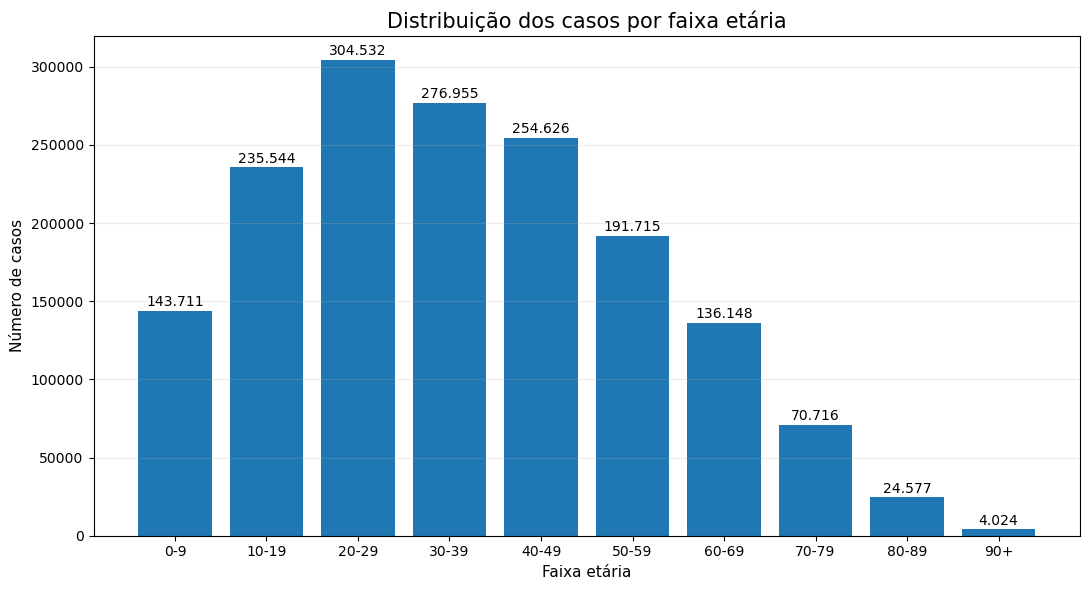

In [94]:
faixas = (
    df_dengue["faixa_etaria"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.bar(
    faixas.index.astype(str),
    faixas.values
)

ax.set_title("Distribuição dos casos por faixa etária")
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Número de casos")

for barra, valor in zip(barras, faixas.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + faixas.max() * 0.01,
        f"{valor:,.0f}".replace(",", "."),
        ha="center"
    )

ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

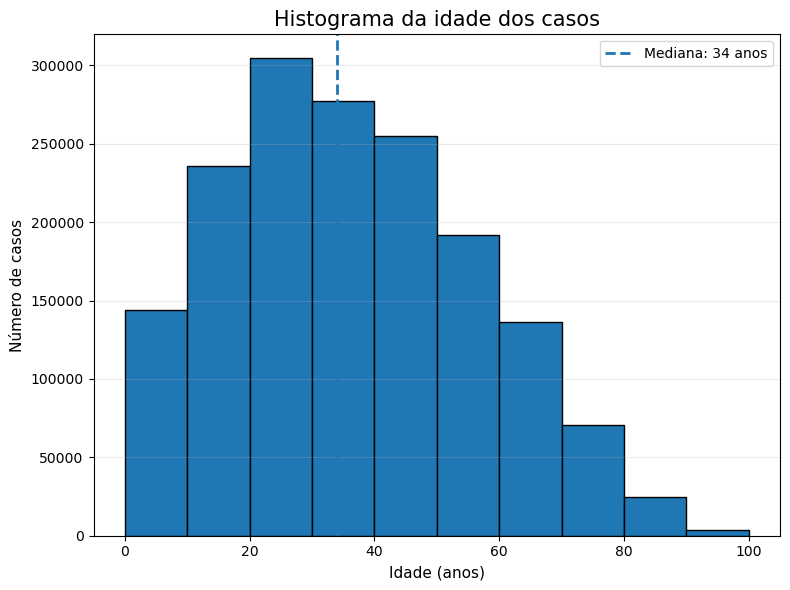

In [95]:
# Histograma: mostra a distribuição da idade de forma mais contínua
idades_validas = df_dengue["idade_anos"].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    idades_validas,
    bins=range(0, 106, 10),
    edgecolor="black"
)

mediana = idades_validas.median()

ax.axvline(
    mediana,
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {mediana:.0f} anos"
)

ax.set_title("Histograma da idade dos casos")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Número de casos")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### 3.3 Estados com maior número de casos

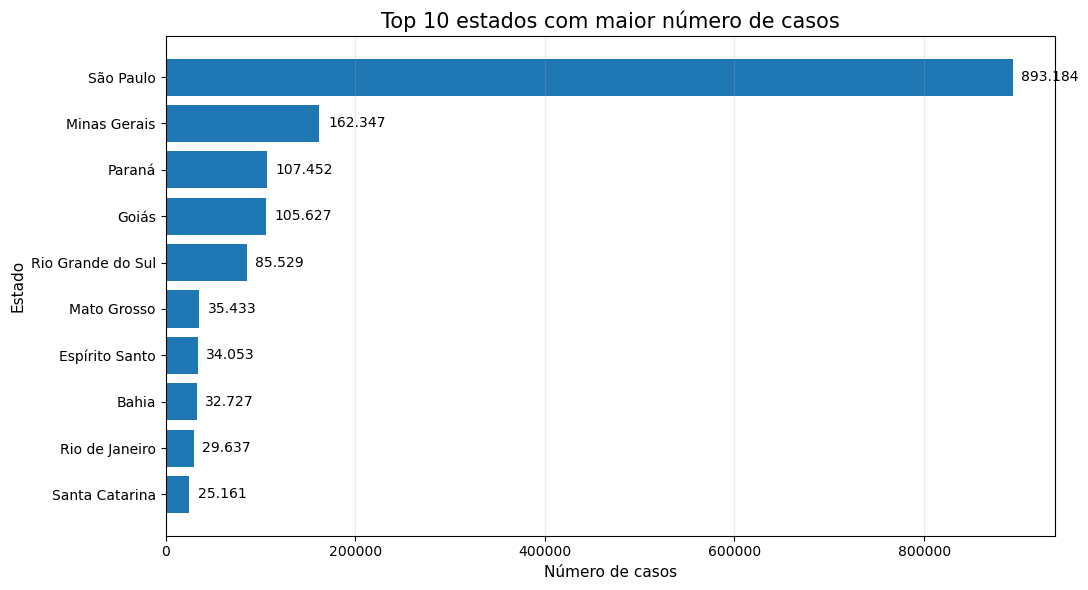

In [96]:
casos_uf = (
    df_dengue["uf_nome"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(
    casos_uf.index,
    casos_uf.values
)

ax.set_title("Top 10 estados com maior número de casos")
ax.set_xlabel("Número de casos")
ax.set_ylabel("Estado")

for barra, valor in zip(barras, casos_uf.values):
    ax.text(
        valor + casos_uf.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center"
    )

ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Fazer a proporção de casos por população

In [97]:
%pip install geobr geopandas -q

Note: you may need to restart the kernel to use updated packages.


In [98]:
!pip install mapclassify

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [99]:
from geobr import read_state
from matplotlib.colors import LogNorm

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


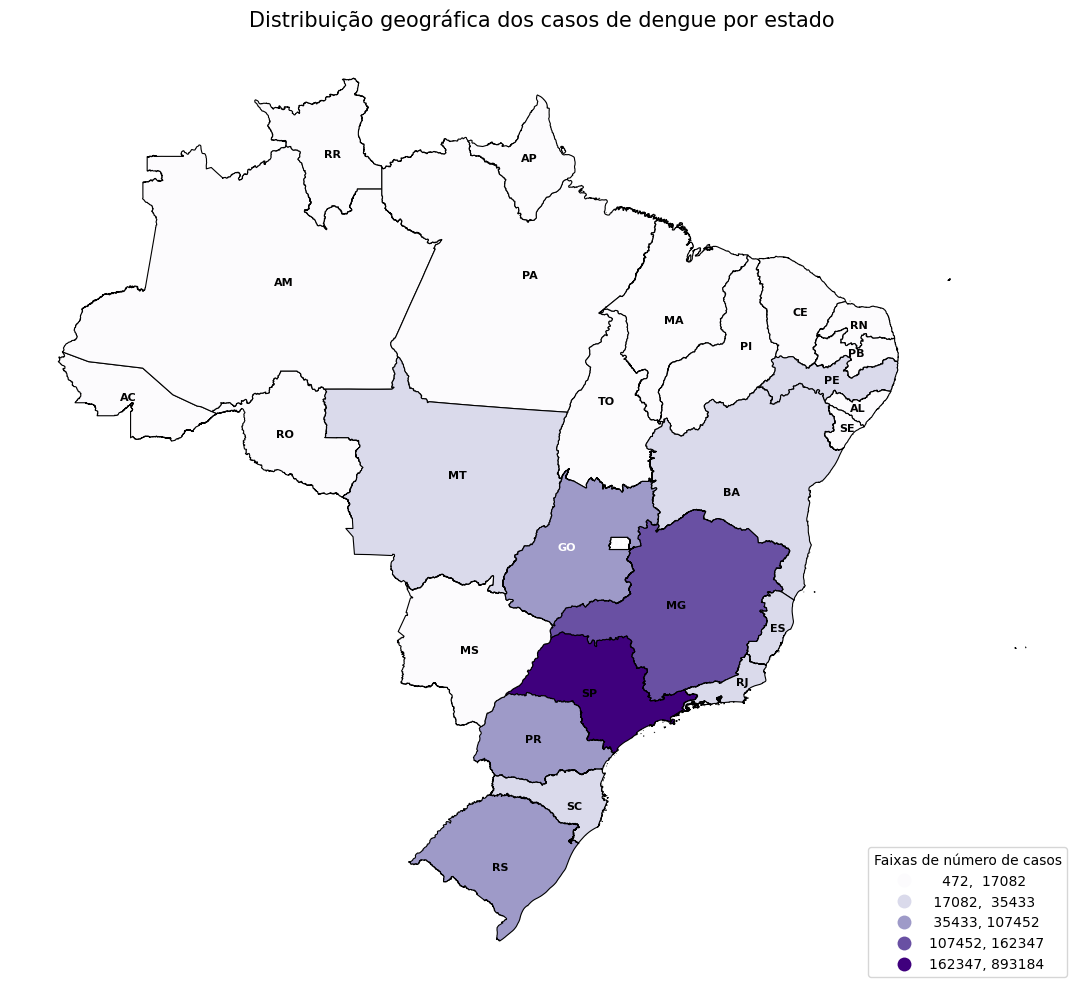

In [100]:
casos_estado = (
    pd.to_numeric(df_dengue["uf"], errors="coerce")
    .value_counts()
    .rename_axis("code_state")
    .reset_index(name="casos")
)

casos_estado["code_state"] = casos_estado["code_state"].astype("Int64")


# ---------------------------------------------------------
# Mapa dos estados do Brasil
# ---------------------------------------------------------

mapa_brasil = read_state(code_state="all", year=2022, show_progress=False)

mapa_brasil["code_state"] = pd.to_numeric(
    mapa_brasil["code_state"], errors="coerce"
).astype("Int64")


# ---------------------------------------------------------
# Junta o mapa com a quantidade de casos
# ---------------------------------------------------------

mapa_casos = mapa_brasil.merge(casos_estado, on="code_state", how="left")

mapa_casos["casos"] = mapa_casos["casos"].fillna(0)


# ---------------------------------------------------------
# Gráfico (com destaque cinza para o menor valor e ajuste de cor)
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 10))

mapa_casos.plot(
    column="casos",
    cmap="Purples",
    scheme="NaturalBreaks",
    k=5,
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "title": "Faixas de número de casos",
        "loc": "lower right",
        "fmt": "{:.0f}",
    },
    # Define uma cor cinza clara bem definida para áreas sem registro ou 0 casos
    missing_kwds={
        "color": "#e0e0e0",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Sem dados / 0 casos",
    },
    ax=ax,
)

# Siglas dos estados com ajuste dinâmico de cor de texto para legibilidade
for _, estado in mapa_casos.iterrows():
    ponto = estado.geometry.representative_point()

    # Cor branca para o fundo muito escuro
    cor_texto = (
        "white" if estado["abbrev_state"] in ["GO", "DF"] else "black"
    )

    ax.text(
        ponto.x,
        ponto.y,
        estado["abbrev_state"],
        ha="center",
        va="center",
        fontsize=8,
        color=cor_texto,
        fontweight="bold",
    )

ax.set_title(
    "Distribuição geográfica dos casos de dengue por estado", fontsize=15
)

ax.axis("off")

plt.tight_layout()
plt.show()

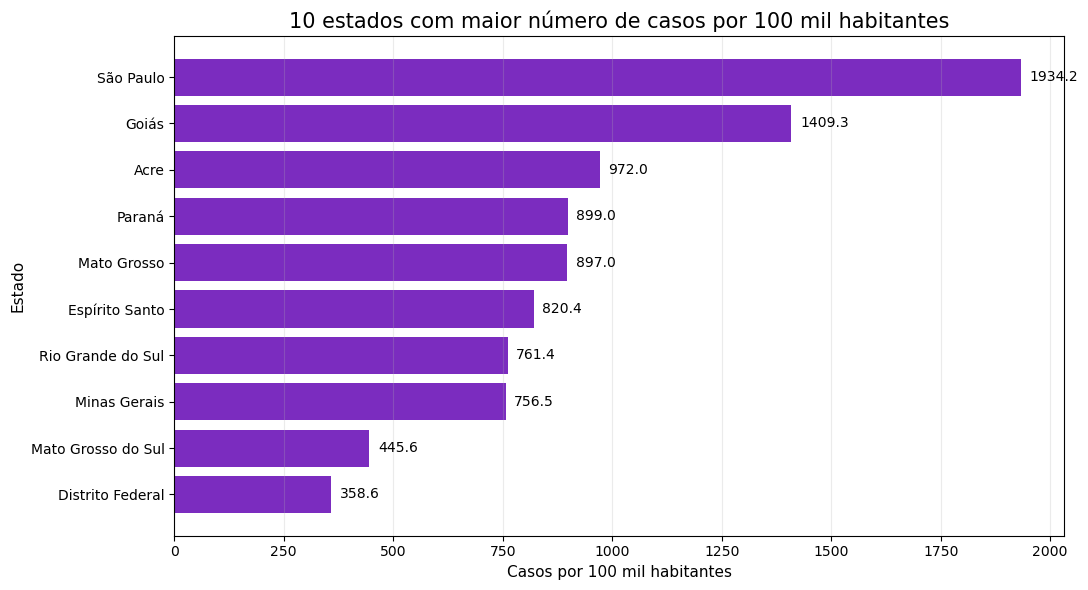

In [ ]:
# ---------------------------------------------------------
# População estimada por estado - IBGE 2026
# ---------------------------------------------------------

populacao_2026 = {
    "Rondônia": 1757338,
    "Acre": 887794,
    "Amazonas": 4360926,
    "Roraima": 761012,
    "Pará": 8756324,
    "Amapá": 809953,
    "Tocantins": 1595994,
    "Maranhão": 7024557,
    "Piauí": 3392617,
    "Ceará": 9302211,
    "Rio Grande do Norte": 3463737,
    "Paraíba": 4182828,
    "Pernambuco": 9583176,
    "Alagoas": 3221128,
    "Sergipe": 2307255,
    "Bahia": 14889472,
    "Minas Gerais": 21460311,
    "Espírito Santo": 4150692,
    "Rio de Janeiro": 17225410,
    "São Paulo": 46179008,
    "Paraná": 11952456,
    "Santa Catarina": 8312759,
    "Rio Grande do Sul": 11233317,
    "Mato Grosso do Sul": 2946317,
    "Mato Grosso": 3950330,
    "Goiás": 7495033,
    "Distrito Federal": 3009996
}


# ---------------------------------------------------------
# Quantidade de casos por estado
# ---------------------------------------------------------

casos_estado = (
    df_dengue["uf_nome"]
    .value_counts()
    .rename("casos")
    .reset_index()
)

casos_estado.columns = ["estado", "casos"]


# ---------------------------------------------------------
# Adiciona população
# ---------------------------------------------------------

casos_estado["populacao"] = (
    casos_estado["estado"]
    .map(populacao_2026)
)


# ---------------------------------------------------------
# Casos por 100 mil habitantes
# ---------------------------------------------------------

casos_estado["casos_por_100_mil"] = (
    casos_estado["casos"]
    / casos_estado["populacao"]
) * 100000


# ---------------------------------------------------------
# Top 10 estados
# ---------------------------------------------------------

top10_proporcao = (
    casos_estado
    .nlargest(10, "casos_por_100_mil")
    .sort_values("casos_por_100_mil")
)


# ---------------------------------------------------------
# Gráfico
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(
    top10_proporcao["estado"],
    top10_proporcao["casos_por_100_mil"],
    color="#7B2CBF"
)

ax.set_title(
    "Top 10 estados com maior número de casos por 100 mil habitantes"
)

ax.set_xlabel("Casos por 100 mil habitantes")
ax.set_ylabel("Estado")


# Valores nas barras
for barra, valor in zip(
    barras,
    top10_proporcao["casos_por_100_mil"]
):
    
    ax.text(
        valor + top10_proporcao["casos_por_100_mil"].max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}",
        va="center"
    )


ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 3.4 Municípios com maior número de casos

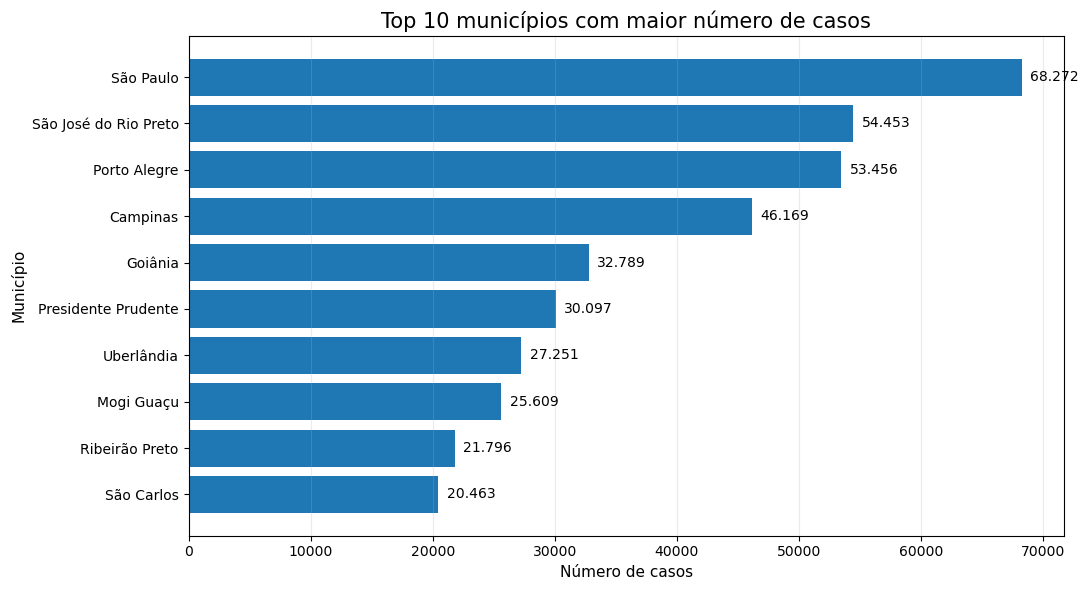

In [102]:
casos_municipio = (
    df_dengue["municipio_nome"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(
    casos_municipio.index,
    casos_municipio.values
)

ax.set_title("Top 10 municípios com maior número de casos")
ax.set_xlabel("Número de casos")
ax.set_ylabel("Município")

for barra, valor in zip(barras, casos_municipio.values):
    ax.text(
        valor + casos_municipio.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center"
    )

ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 3.5 Distribuição dos casos ao longo dos meses

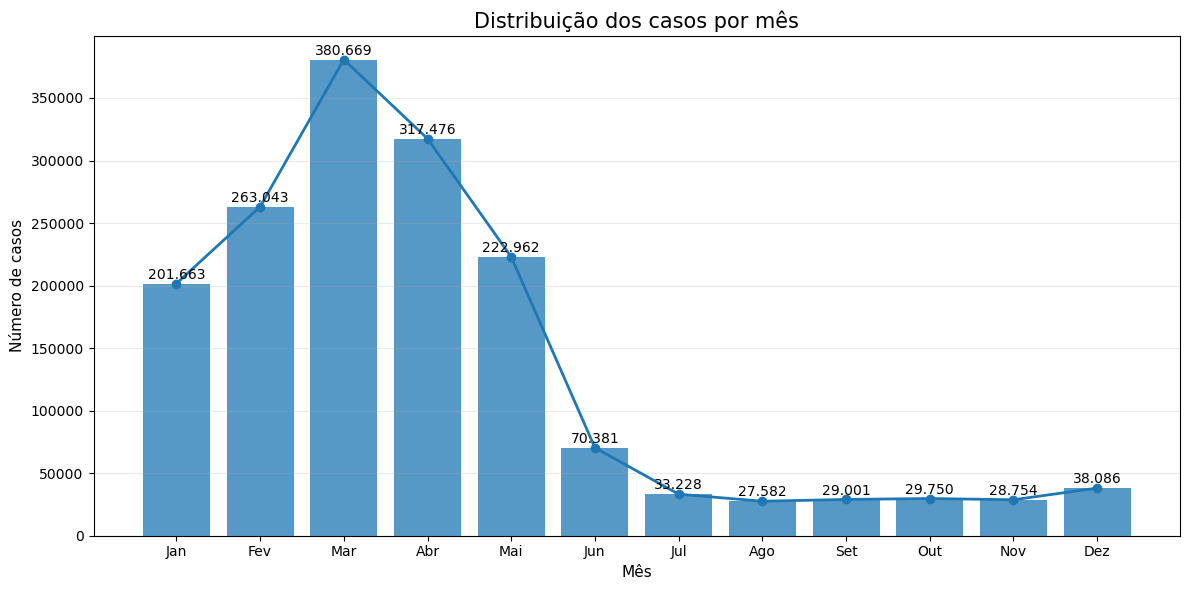

A base contém somente o ano de 2026. Por isso, não há comparação entre anos nesta versão dos dados.


In [106]:
casos_mes = (
    df_dengue
    .groupby("mes_numero")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

meses = [mapa_meses[i] for i in range(1, 13)]

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    meses,
    casos_mes.values,
    alpha=0.75,
    label="Casos"
)

ax.plot(
    meses,
    casos_mes.values,
    marker="o",
    linewidth=2
)

for i, valor in enumerate(casos_mes.values):
    if valor > 0:
        ax.text(
            i,
            valor + casos_mes.max() * 0.01,
            f"{valor:,.0f}".replace(",", "."),
            ha="center"
        )

data_final = df_dengue["data_primeiros_sintomas"].max()

ax.set_title(
    f"Distribuição dos casos por mês"
)
ax.set_xlabel("Mês")
ax.set_ylabel("Número de casos")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print(
    "A base contém somente o ano de 2026. "
    "Por isso, não há comparação entre anos nesta versão dos dados."
)

### 3.4 Municípios com maior número de casos

### 3.6 Sintomas mais frequentes

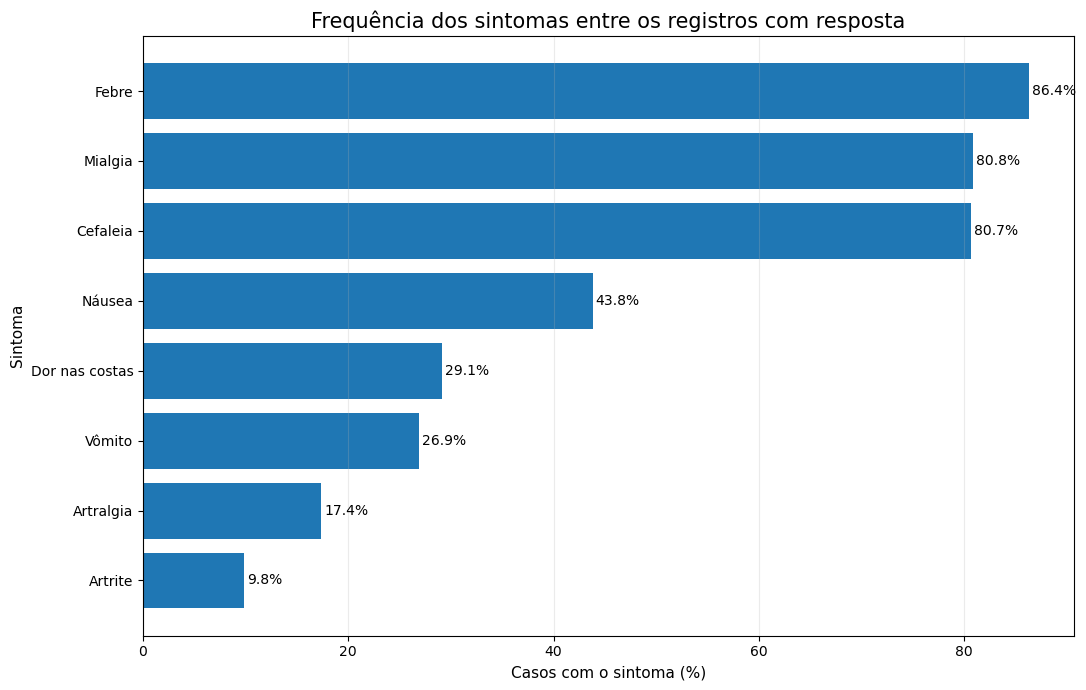

,Sintoma,Casos com sintoma,Respostas conhecidas,Percentual
0,Febre,1373858,1590739,86.366022
1,Mialgia,1285807,1590739,80.830796
2,Cefaleia,1283296,1590739,80.672945
4,Náusea,696951,1590739,43.813033
5,Dor nas costas,462866,1590739,29.097545
3,Vômito,427183,1590739,26.854374
7,Artralgia,276009,1590739,17.350992
6,Artrite,156522,1590739,9.839578


In [104]:
resultado_sintomas = []

for sintoma in sintomas:
    serie = df_dengue[sintoma]

    conhecidos = serie.isin([1, 2]).sum()
    casos_com_sintoma = (serie == 1).sum()


    if conhecidos > 0:
        percentual = casos_com_sintoma / conhecidos * 100
    else:
        percentual = 0

    resultado_sintomas.append([
        nomes_sintomas[sintoma],
        casos_com_sintoma,
        conhecidos,
        percentual
    ])

tabela_sintomas = pd.DataFrame(
    resultado_sintomas,
    columns=[
        "Sintoma",
        "Casos com sintoma",
        "Respostas conhecidas",
        "Percentual"
    ]
).sort_values(
    "Percentual",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    tabela_sintomas["Sintoma"],
    tabela_sintomas["Percentual"]
)

ax.set_title("Frequência dos sintomas entre os registros com resposta")
ax.set_xlabel("Casos com o sintoma (%)")
ax.set_ylabel("Sintoma")

for barra, valor in zip(
    barras,
    tabela_sintomas["Percentual"]
):
    ax.text(
        valor + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        va="center"
    )

ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

tabela_sintomas.sort_values(
    "Percentual",
    ascending=False
)
#juntar artrite e artralgia

### 3.7 Gráfico de pizza/rosca — distribuição por sexo

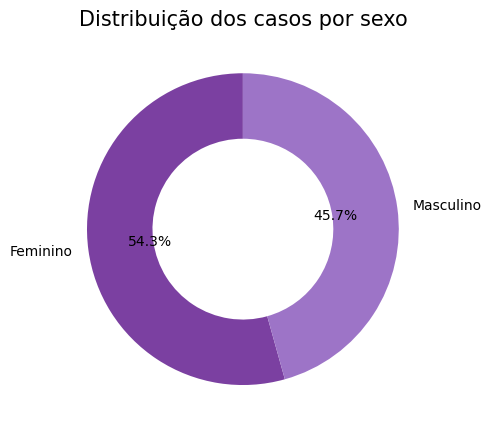

In [105]:
mapa_sexo = {
    "F": "Feminino",
    "M": "Masculino",
    "I": "Ignorado"
}

sexo = (
    df_dengue["sexo"]
    .map(mapa_sexo)
    .value_counts()
)

if "Ignorado" in sexo.index:
    sexo = sexo.drop("Ignorado")

cores_roxo = ["#7B40A1", "#9D74C7"] 

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    sexo.values,
    labels=sexo.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=cores_roxo,
    wedgeprops={"width": 0.42}
)

ax.set_title("Distribuição dos casos por sexo")

plt.tight_layout()
plt.show()

PERGUNTAS:

- Qual é a distribuição dos casos por faixa etária?
- Quais estados e municípios concentram o maior número de casos?
- Como os casos se distribuem ao longo dos anos e meses?
- Quais são os sintomas mais frequentes?

- Qual é o perfil dos casos classificados como graves?
- Quais sintomas são mais frequentes entre os casos graves?
- Quais grupos apresentam maior proporção de hospitalização?
- Quantos casos evoluíram para óbito e qual é o perfil desses casos?
- Existe relação entre hospitalização e evolução dos casos?
- Quais municípios apresentam maior quantidade e maior proporção de casos graves?
- Existe relação entre a quantidade de sintomas e a gravidade do caso?
- Existem diferenças na ocorrência dos sintomas segundo faixa etária, sexo ou raça?